# Exercise 2 — Disease Susceptibility Prediction

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid")

In [2]:
DATA_URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]

df = pd.read_csv(DATA_URL, names=columns)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
display(df.isnull().sum())
display(df.describe().T)

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [4]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 614
Testing samples: 154


In [5]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


In [6]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

results = pd.DataFrame({
    "Actual Disease Status": y_test.values,
    "Predicted Disease Status": y_pred,
    "Disease Probability": y_prob
})

display(results.head(10))

,Actual Disease Status,Predicted Disease Status,Disease Probability
0,0,1,0.616674
1,0,0,0.112781
2,0,0,0.272540
3,1,0,0.286682
4,0,0,0.004481
5,0,0,0.189049
6,1,0,0.468429
7,1,1,0.916977
8,0,0,0.103246
9,0,1,0.781131


In [7]:
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC: {auc:.4f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.7143
ROC-AUC: 0.8230
              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154



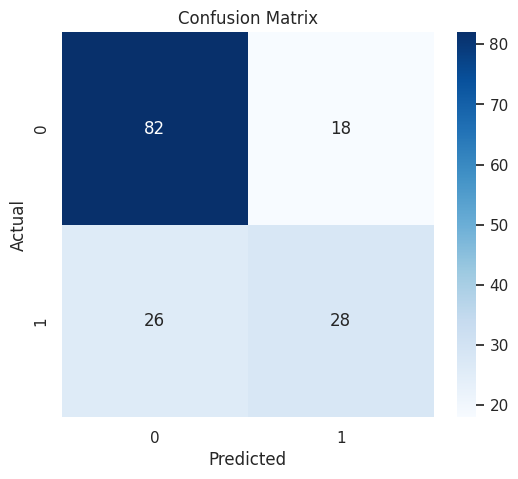

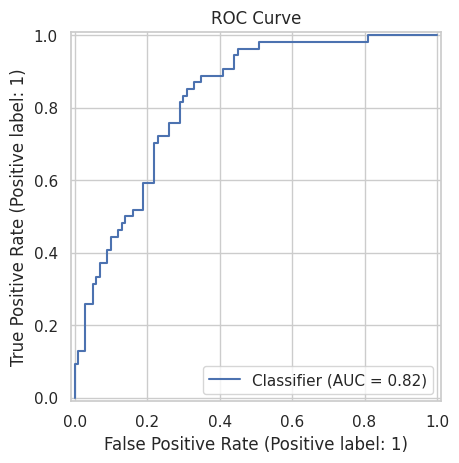

In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve")
plt.show()

In [9]:
new_person = pd.DataFrame({
    "Pregnancies": [2],
    "Glucose": [140],
    "BloodPressure": [80],
    "SkinThickness": [30],
    "Insulin": [100],
    "BMI": [32.0],
    "DiabetesPedigreeFunction": [0.5],
    "Age": [35]
})

probability = model.predict_proba(new_person)[0, 1]
prediction = model.predict(new_person)[0]

print(f"Disease probability: {probability:.2%}")
print("Prediction:", "Susceptible" if prediction == 1 else "Not Susceptible")

Disease probability: 39.13%
Prediction: Not Susceptible
